# Xi Phase Map

Time-colored phase trajectories for selected countries.

- x-axis: `xi`
- y-axis ratio mode:
  - `share` -> configurable via `share_metric` (`share`, `share_amp_1`, `share_amp_2`)
  - `amplification` -> `xi / xi_dir`

In [126]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz_xi as viz_xi
importlib.reload(viz_xi)

load_xi_data = viz_xi.load_xi_data
select_phase_map_countries = viz_xi.select_phase_map_countries
plot_xi_phase_map = viz_xi.plot_xi_phase_map

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [127]:
cfg = load_config('config/default.yaml')
variant = None  # None -> inferred from config
ratio_mode = 'share'  # 'share' or 'amplification'
share_metric = 'share_amp_1'  # used when ratio_mode == 'share'
only_ok = True
# Truncated Oranges: avoids near-white low end while keeping early years lighter.
base_cmap = plt.get_cmap('Oranges')
cmap = LinearSegmentedColormap.from_list(
    'Oranges_trunc',
    base_cmap(np.linspace(0.22, 1.0, 256))
)
year_step = 5  # keep one point every N years

In [128]:
df = load_xi_data(cfg=cfg, variant=variant)
print('rows:', len(df))
print('years:', int(df['year'].min()), 'to', int(df['year'].max()))
if 'status' in df.columns:
    print('status counts:', df['status'].value_counts(dropna=False).to_dict())

rows: 2268
years: 1995 to 2022
status counts: {'ok': 2268}


In [129]:
auto_phase_countries = select_phase_map_countries(
    df,
    ratio_mode=ratio_mode,
    share_metric=share_metric,
    only_ok=only_ok,
)
print('auto placeholders:', auto_phase_countries)

# Override manually if needed
phase_countries = ['CHN', 'IND', 'GBR', 'DEU', 'USA', 'ZAF']

auto placeholders: ['USA', 'CHN', 'NOR', 'AUS', 'IDN']


phase rows: 486 from original: 2268


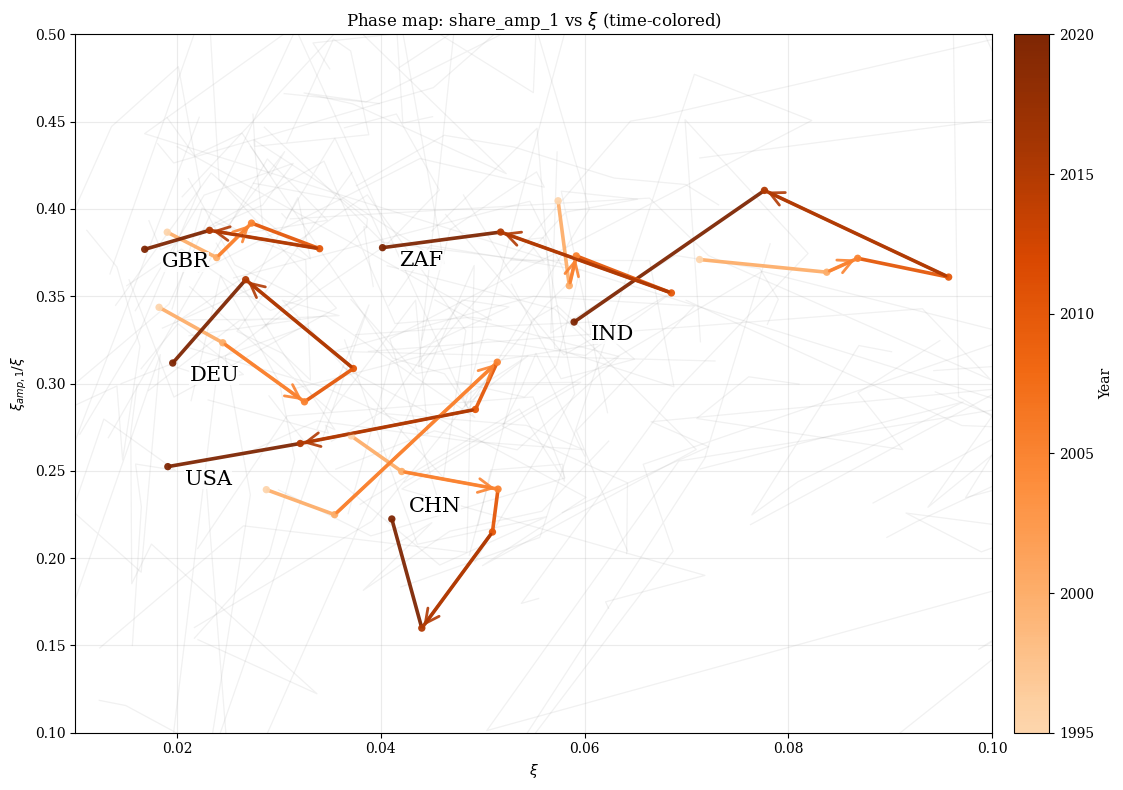

In [130]:
base_year = int(df['year'].min())
df_phase = df[(df['year'] - base_year) % year_step == 0].copy()
print('phase rows:', len(df_phase), 'from original:', len(df))

ratio_label = share_metric if ratio_mode == 'share' else ratio_mode

fig, ax = plt.subplots(figsize=(12, 8))
plot_xi_phase_map(
    df_phase,
    countries=phase_countries,
    ratio_mode=ratio_mode,
    share_metric=share_metric,
    only_ok=only_ok,
    title=rf'Phase map: {ratio_label} vs $\xi$ (time-colored)',
    cmap=cmap,
    lw=2.6,
    point_size=28,
    show_end_labels=True,
    end_label_dx_pts=12,
    end_label_dy_pts=9,
    end_label_bbox_alpha=0.85,
    show_background=True,
    bg_color='0.55',
    bg_alpha=0.12,
    bg_lw=0.9,
    show_flow_arrows=True,
    flow_arrow_step=2,
    flow_arrow_lw=2,
    flow_arrow_scale=25,
    ax=ax,
)
ax.set_xlim(0.01, 0.1)
ax.set_ylim(0.1, 0.5)
plt.tight_layout()
plt.show()